Raw data (first rows):
                measured_at  energy_consumption_kwh  temperature_celsius  \
0 2021-01-01 00:00:00+00:00              142.248994                 -0.3   
1 2021-01-01 01:00:00+00:00              133.500684                 -0.6   
2 2021-01-01 02:00:00+00:00              128.560861                 -0.2   
3 2021-01-01 03:00:00+00:00              127.513333                 -0.3   
4 2021-01-01 04:00:00+00:00              126.810857                 -0.3   
5 2021-01-01 05:00:00+00:00              121.279305                 -0.5   
6 2021-01-01 06:00:00+00:00              126.026241                 -0.5   
7 2021-01-01 07:00:00+00:00              133.067247                 -0.4   
8 2021-01-01 08:00:00+00:00              140.917220                 -0.7   
9 2021-01-01 09:00:00+00:00              147.253891                 -0.7   

   heating_demand  
0            18.3  
1            18.6  
2            18.2  
3            18.3  
4            18.3  
5            18.5  


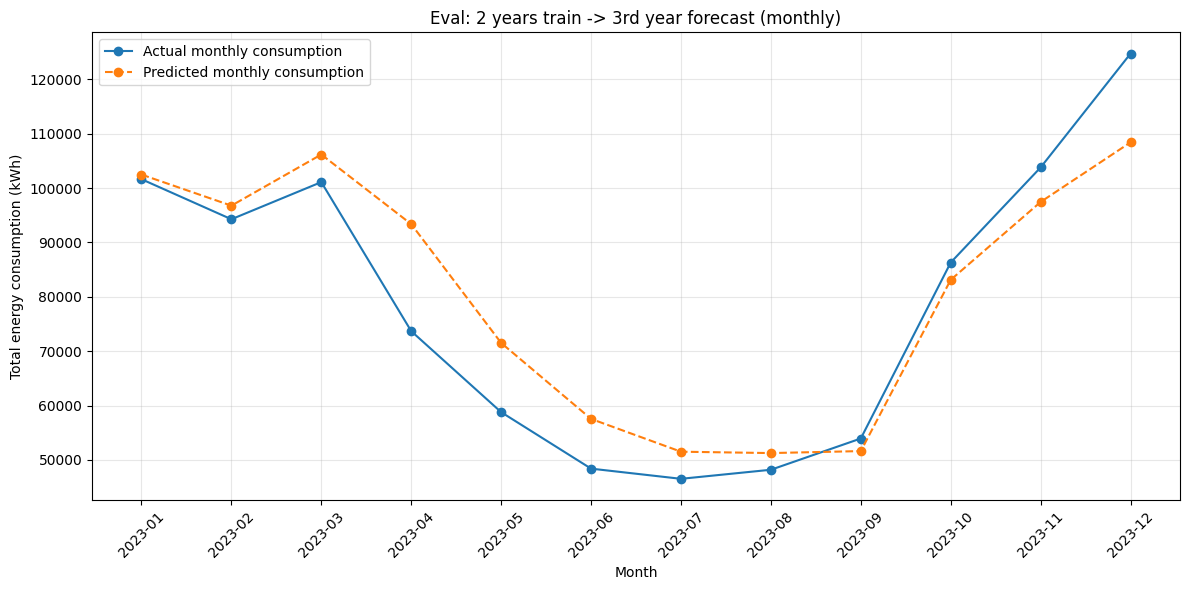


=== FULL-HISTORY MODEL (train on all data, forecast next year) ===
Full-history training samples: (32784, 72, 3) (32784,)
[Epoch   1/5] train NLL: 0.5389
[Epoch   2/5] train NLL: -0.5443
[Epoch   3/5] train NLL: -0.9033
[Epoch   4/5] train NLL: -1.0092
[Epoch   5/5] train NLL: -1.0423

Future horizon hours (beyond data end): 8760


/tmp/ipython-input-21907127.py:434: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  ts_future = pd.date_range(
/tmp/ipython-input-21907127.py:441: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  hist_monthly = df.resample("M", on=DATE_COL)[TARGET_COL].sum().reset_index()
/tmp/ipython-input-21907127.py:447: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_monthly = df_future.resample("M", on="timestamp")["y_pred"].sum().reset_index()


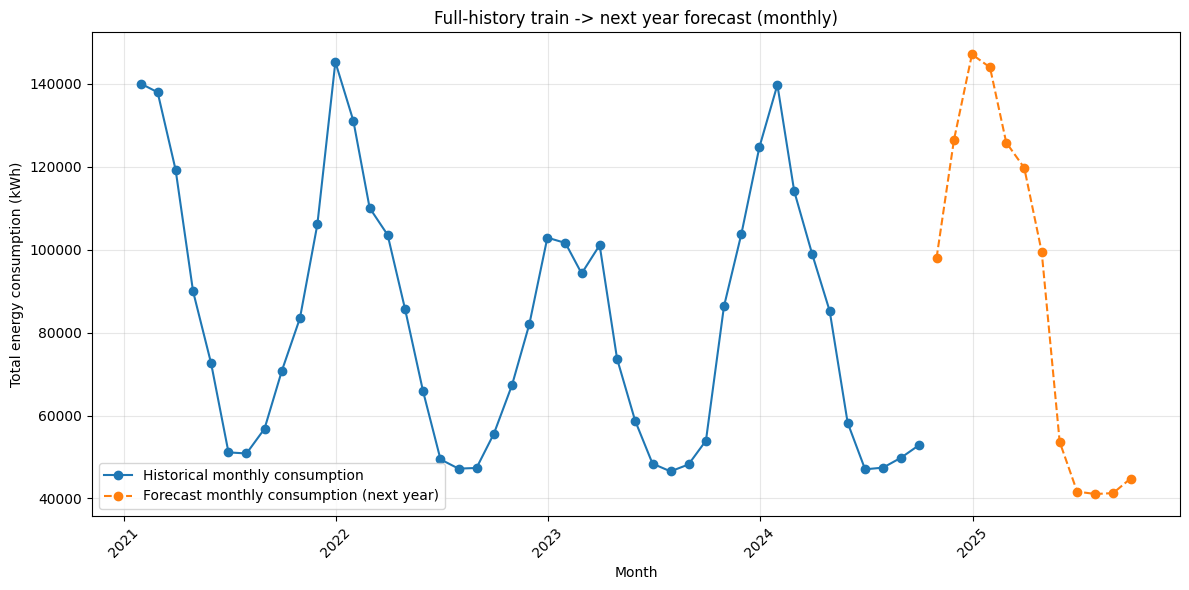

In [6]:
# ============================================================
# IMPORTS & BASIC SETUP
# ============================================================
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(0)
np.random.seed(0)

# ============================================================
# CONFIG  (FASTER VERSION)
# ============================================================
FILE_PATH       = "20251111_JUNCTION_training_wiithhtemp.xlsx"
SHEET_NAME      = "training_data_2021_2024"
DATE_COL        = "measured_at"
TARGET_COL      = "energy_consumption_kwh"
TEMP_COL        = "temperature_celsius"
DEMAND_COL      = "heating_demand"

HOURS_PER_DAY   = 24
CONTEXT_DAYS    = 3                  # shorter context -> faster
CONTEXT_LEN     = CONTEXT_DAYS * HOURS_PER_DAY

FORECAST_YEARS  = 1
FORECAST_HOURS  = FORECAST_YEARS * 365 * HOURS_PER_DAY  # 1 year ahead

BATCH_SIZE      = 256                # bigger batch -> fewer steps
EPOCHS_EVAL     = 5                  # fewer epochs -> faster
EPOCHS_FULL     = 5
LR              = 2e-3               # slightly higher LR for fewer epochs
HIDDEN_SIZE     = 8                  # smaller GRU
NUM_LAYERS      = 1                  # shallower GRU

# ============================================================
# 1. LOAD DATA
# ============================================================
df = pd.read_excel(FILE_PATH, sheet_name=SHEET_NAME)
df[DATE_COL] = pd.to_datetime(df[DATE_COL])
df = df.sort_values(DATE_COL).reset_index(drop=True)

print("Raw data (first rows):")
print(df[[DATE_COL, TARGET_COL, TEMP_COL, DEMAND_COL]].head(10))

print("\nData span:", df[DATE_COL].min(), "->", df[DATE_COL].max())
print("Total rows (hours):", len(df))

# ============================================================
# 2. MODEL + LOSS
# ============================================================
class DeepARModel(nn.Module):
    def __init__(self, input_size=3, hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS):
        super().__init__()
        self.rnn = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
        )
        self.fc_mu    = nn.Linear(hidden_size, 1)
        self.fc_sigma = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x: (batch, seq_len, input_size)
        out, _ = self.rnn(x)
        last = out[:, -1, :]                   # (batch, hidden)
        mu = self.fc_mu(last).squeeze(-1)      # (batch,)
        sigma = torch.nn.functional.softplus(
            self.fc_sigma(last)
        ).squeeze(-1) + 1e-6
        return mu, sigma


def gaussian_nll(y, mu, sigma):
    # Negative log-likelihood for Gaussian
    return 0.5 * torch.log(2 * math.pi * sigma**2) + (y - mu) ** 2 / (2 * sigma**2)


class SeqDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


def build_sequences(y_norm, temp_norm, dem_norm, start_idx, end_idx, context_len):
    """
    Sliding windows over [start_idx, end_idx) where each sample:
      - input: last `context_len` hours
      - target: next hour
    """
    X_list, y_list = [], []
    max_start = end_idx - context_len - 1  # target at start+context_len
    for s in range(start_idx, max_start + 1):
        e = s + context_len
        tgt = e

        seq_y    = y_norm[s:e]
        seq_temp = temp_norm[s:e]
        seq_dem  = dem_norm[s:e]

        X_seq = np.stack([seq_y, seq_temp, seq_dem], axis=-1)  # (context_len, 3)
        y_tgt = y_norm[tgt]

        X_list.append(X_seq)
        y_list.append(y_tgt)

    X = np.stack(X_list, axis=0)  # (num_samples, context_len, 3)
    y = np.array(y_list)
    return X, y


def train_deepar(X_train, y_train, epochs, lr):
    dataset = SeqDataset(X_train, y_train)
    loader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=0,      # bump to 2/4 if your env supports it
        pin_memory=torch.cuda.is_available(),
    )

    model = DeepARModel(input_size=3, hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    for epoch in range(1, epochs + 1):
        model.train()
        epoch_loss = 0.0
        n_samples  = 0

        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()
            mu, sigma = model(X_batch)
            loss = gaussian_nll(y_batch, mu, sigma).mean()
            loss.backward()
            optimizer.step()

            bs = y_batch.size(0)
            epoch_loss += loss.item() * bs
            n_samples  += bs

        print(f"[Epoch {epoch:3d}/{epochs}] train NLL: {epoch_loss / n_samples:.4f}")

    return model

# ============================================================
# 3. SPLIT FOR EVALUATION: 2-YEAR TRAIN -> 3RD YEAR TEST
# ============================================================
start_date = df[DATE_COL].min().normalize()
train_eval_end_date = start_date + pd.DateOffset(years=2)          # end of 2 years
eval_end_date       = train_eval_end_date + pd.DateOffset(years=1) # +1 year

train_mask_eval = df[DATE_COL] < train_eval_end_date
eval_mask       = (df[DATE_COL] >= train_eval_end_date) & (df[DATE_COL] < eval_end_date)

if not train_mask_eval.any() or not eval_mask.any():
    raise ValueError("Not enough data to create 2-year train / 1-year eval split.")

train_start_idx = np.where(train_mask_eval)[0][0]
train_end_idx   = np.where(train_mask_eval)[0][-1] + 1
eval_start_idx  = np.where(eval_mask)[0][0]
eval_end_idx    = np.where(eval_mask)[0][-1] + 1

print("\n=== EVAL SPLIT (2y train -> 3rd year test) ===")
print("Train eval period :", df[DATE_COL].iloc[train_start_idx], "->", df[DATE_COL].iloc[train_end_idx - 1])
print("Eval period       :", df[DATE_COL].iloc[eval_start_idx],  "->", df[DATE_COL].iloc[eval_end_idx - 1])

# ============================================================
# 4. NORMALIZATION (BASED ON EVAL TRAIN PERIOD)
# ============================================================
y_all    = df[TARGET_COL].values.astype(float)
temp_all = df[TEMP_COL].values.astype(float)
dem_all  = df[DEMAND_COL].values.astype(float)

y_train_eval_arr    = y_all[train_start_idx:train_end_idx]
temp_train_eval_arr = temp_all[train_start_idx:train_end_idx]
dem_train_eval_arr  = dem_all[train_start_idx:train_end_idx]

y_mean, y_std       = y_train_eval_arr.mean(), y_train_eval_arr.std() or 1.0
temp_mean, temp_std = temp_train_eval_arr.mean(), temp_train_eval_arr.std() or 1.0
dem_mean, dem_std   = dem_train_eval_arr.mean(), dem_train_eval_arr.std() or 1.0

y_norm    = (y_all - y_mean) / y_std
temp_norm = (temp_all - temp_mean) / temp_std
dem_norm  = (dem_all - dem_mean) / dem_std

print(f"\nEval-train target mean: {y_mean:.3f}, std: {y_std:.3f}")

# ============================================================
# 5. BUILD TRAINING SEQUENCES FOR EVAL MODEL
# ============================================================
X_train_eval, y_train_eval_seq = build_sequences(
    y_norm, temp_norm, dem_norm,
    start_idx=train_start_idx,
    end_idx=train_end_idx,
    context_len=CONTEXT_LEN,
)

print("Eval-model training samples:", X_train_eval.shape, y_train_eval_seq.shape)

# ============================================================
# 6. TRAIN EVAL MODEL
# ============================================================
print("\n=== TRAINING EVAL MODEL (2 years) ===")
eval_model = train_deepar(
    X_train=X_train_eval,
    y_train=y_train_eval_seq,
    epochs=EPOCHS_EVAL,
    lr=LR,
)

# ============================================================
# 7. EVAL FORECAST: 3RD YEAR HOURLY, THEN AGGREGATE MONTHLY
# ============================================================
eval_model.eval()

eval_horizon_hours = eval_end_idx - eval_start_idx
print("\nEval horizon hours:", eval_horizon_hours)

eval_block_start = eval_start_idx - CONTEXT_LEN
eval_block_end   = eval_start_idx + eval_horizon_hours   # exclusive
eval_block_len   = CONTEXT_LEN + eval_horizon_hours

if eval_block_start < 0:
    raise ValueError("Not enough history before eval start for CONTEXT_LEN.")

temp_block_eval = temp_norm[eval_block_start:eval_block_end]
dem_block_eval  = dem_norm[eval_block_start:eval_block_end]

y_hist_norm_eval = np.zeros(eval_block_len, dtype=float)
y_hist_norm_eval[:CONTEXT_LEN] = y_norm[eval_block_start:eval_start_idx]

pred_norm_eval_list = []

with torch.no_grad():
    for t in range(CONTEXT_LEN, eval_block_len):
        start = t - CONTEXT_LEN
        end   = t

        seq_y    = y_hist_norm_eval[start:end]
        seq_temp = temp_block_eval[start:end]
        seq_dem  = dem_block_eval[start:end]

        X_seq = np.stack([seq_y, seq_temp, seq_dem], axis=-1)[None, ...]  # (1, ctx, 3)
        X_tensor = torch.tensor(X_seq, dtype=torch.float32).to(device)

        mu, sigma = eval_model(X_tensor)
        y_pred_norm = mu.squeeze().item()

        y_hist_norm_eval[t] = y_pred_norm
        pred_norm_eval_list.append(y_pred_norm)

pred_norm_eval_arr = np.array(pred_norm_eval_list[-eval_horizon_hours:])
y_pred_eval_future = pred_norm_eval_arr * y_std + y_mean

y_true_eval_future = y_all[eval_start_idx:eval_end_idx]
ts_eval_future     = df[DATE_COL].values[eval_start_idx:eval_end_idx]

# ============================================================
# 8. MONTHLY METRICS (EVAL) – ERRORS PER MONTH
# ============================================================
def safe_mape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mask = y_true != 0
    if not np.any(mask):
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100.0

def smape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.abs(y_true) + np.abs(y_pred)
    mask = denom != 0
    if not np.any(mask):
        return np.nan
    return np.mean(2.0 * np.abs(y_true[mask] - y_pred[mask]) / denom[mask]) * 100.0

df_eval = pd.DataFrame({
    "timestamp": ts_eval_future,
    "y_true":    y_true_eval_future,
    "y_pred":    y_pred_eval_future,
})

# FIX: use dt.to_period("M") instead of astype("datetime64[M]")
df_eval["month"] = pd.to_datetime(df_eval["timestamp"]).dt.to_period("M")

monthly = df_eval.groupby("month").agg(
    y_true=("y_true", "sum"),
    y_pred=("y_pred", "sum"),
).reset_index()

monthly["mae"]  = np.abs(monthly["y_true"] - monthly["y_pred"])
monthly["mape"] = [
    safe_mape([yt], [yp]) for yt, yp in zip(monthly["y_true"], monthly["y_pred"])
]

overall_mae   = np.mean(np.abs(df_eval["y_true"] - df_eval["y_pred"]))
overall_mse   = np.mean((df_eval["y_true"] - df_eval["y_pred"]) ** 2)
overall_rmse  = np.sqrt(overall_mse)
overall_mape  = safe_mape(df_eval["y_true"], df_eval["y_pred"])
overall_smape = smape(df_eval["y_true"], df_eval["y_pred"])
rel_mae_pct   = overall_mae / np.mean(np.abs(df_eval["y_true"])) * 100.0

print("\n=== MONTHLY EVAL METRICS (2y train -> 3rd year) ===")
print(monthly[["month", "y_true", "y_pred", "mae", "mape"]])
print("\n=== OVERALL EVAL METRICS (hourly, 1-year) ===")
print(f"MAE          : {overall_mae:.3f}")
print(f"MSE          : {overall_mse:.3f}")
print(f"RMSE         : {overall_rmse:.3f}")
print(f"MAPE         : {overall_mape:.2f}%")
print(f"sMAPE        : {overall_smape:.2f}%")
print(f"Relative MAE : {rel_mae_pct:.2f}% of average actual")

# ============================================================
# 9. PLOT 1 – 2-YEAR TRAIN, 3RD YEAR MONTHLY ACTUAL VS PRED
# ============================================================
plt.figure(figsize=(12, 6))
plt.plot(
    monthly["month"].astype(str),
    monthly["y_true"],
    marker="o",
    label="Actual monthly consumption",
)
plt.plot(
    monthly["month"].astype(str),
    monthly["y_pred"],
    marker="o",
    linestyle="--",
    label="Predicted monthly consumption",
)
plt.xticks(rotation=45)
plt.title("Eval: 2 years train -> 3rd year forecast (monthly)")
plt.xlabel("Month")
plt.ylabel("Total energy consumption (kWh)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# 10. FULL-HISTORY MODEL: TRAIN ON ALL DATA, PREDICT NEXT YEAR
# ============================================================
print("\n=== FULL-HISTORY MODEL (train on all data, forecast next year) ===")

y_mean_full, y_std_full       = y_all.mean(), y_all.std() or 1.0
temp_mean_full, temp_std_full = temp_all.mean(), temp_all.std() or 1.0
dem_mean_full, dem_std_full   = dem_all.mean(), dem_all.std() or 1.0

y_norm_full    = (y_all - y_mean_full) / y_std_full
temp_norm_full = (temp_all - temp_mean_full) / temp_std_full
dem_norm_full  = (dem_all - dem_mean_full) / dem_std_full

X_train_full, y_train_full = build_sequences(
    y_norm_full, temp_norm_full, dem_norm_full,
    start_idx=0,
    end_idx=len(df),
    context_len=CONTEXT_LEN,
)

print("Full-history training samples:", X_train_full.shape, y_train_full.shape)

full_model = train_deepar(
    X_train=X_train_full,
    y_train=y_train_full,
    epochs=EPOCHS_FULL,
    lr=LR,
)

# ============================================================
# 11. FUTURE FORECAST: 1 YEAR BEYOND DATA END (NO GROUND TRUTH)
# ============================================================
full_model.eval()

future_horizon_hours = FORECAST_HOURS
print("\nFuture horizon hours (beyond data end):", future_horizon_hours)

y_context_future    = y_norm_full[-CONTEXT_LEN:]
temp_context_future = temp_norm_full[-CONTEXT_LEN:]
dem_context_future  = dem_norm_full[-CONTEXT_LEN:]

if len(temp_norm_full) < future_horizon_hours:
    raise ValueError("Not enough history to reuse exogenous pattern for future horizon.")

temp_future_pattern = temp_norm_full[-future_horizon_hours:]
dem_future_pattern  = dem_norm_full[-future_horizon_hours:]

temp_block_future = np.concatenate([temp_context_future, temp_future_pattern])
dem_block_future  = np.concatenate([dem_context_future, dem_future_pattern])

future_block_len = CONTEXT_LEN + future_horizon_hours

y_hist_norm_future = np.zeros(future_block_len, dtype=float)
y_hist_norm_future[:CONTEXT_LEN] = y_context_future

pred_norm_future_list = []

with torch.no_grad():
    for t in range(CONTEXT_LEN, future_block_len):
        start = t - CONTEXT_LEN
        end   = t

        seq_y    = y_hist_norm_future[start:end]
        seq_temp = temp_block_future[start:end]
        seq_dem  = dem_block_future[start:end]

        X_seq = np.stack([seq_y, seq_temp, seq_dem], axis=-1)[None, ...]
        X_tensor = torch.tensor(X_seq, dtype=torch.float32).to(device)

        mu, sigma = full_model(X_tensor)
        y_pred_norm = mu.squeeze().item()

        y_hist_norm_future[t] = y_pred_norm
        pred_norm_future_list.append(y_pred_norm)

pred_norm_future_arr = np.array(pred_norm_future_list[-future_horizon_hours:])
y_pred_future = pred_norm_future_arr * y_std_full + y_mean_full

last_ts = df[DATE_COL].iloc[-1]
ts_future = pd.date_range(
    start=last_ts + pd.Timedelta(hours=1),
    periods=future_horizon_hours,
    freq="H",
    tz=last_ts.tz if hasattr(last_ts, "tz") else None,
)

hist_monthly = df.resample("M", on=DATE_COL)[TARGET_COL].sum().reset_index()

df_future = pd.DataFrame({
    "timestamp": ts_future,
    "y_pred":    y_pred_future,
})
future_monthly = df_future.resample("M", on="timestamp")["y_pred"].sum().reset_index()

# ============================================================
# 12. PLOT 2 – HISTORY + FUTURE YEAR (MONTHLY)
# ============================================================
plt.figure(figsize=(12, 6))
plt.plot(
    hist_monthly[DATE_COL],
    hist_monthly[TARGET_COL],
    marker="o",
    label="Historical monthly consumption",
)
plt.plot(
    future_monthly["timestamp"],
    future_monthly["y_pred"],
    marker="o",
    linestyle="--",
    label="Forecast monthly consumption (next year)",
)
plt.xticks(rotation=45)
plt.title("Full-history train -> next year forecast (monthly)")
plt.xlabel("Month")
plt.ylabel("Total energy consumption (kWh)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
